### Phần 1: Làm sạch dữ liệu
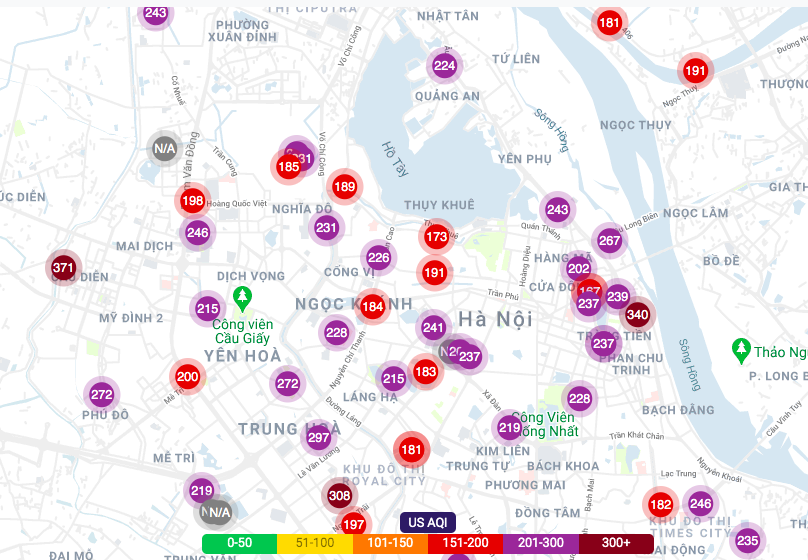



Notebook này trình bày **quy trình xử lý và làm sạch dữ liệu chất lượng không khí Hà Nội**, bao gồm:
1. Xác định và loại bỏ giá trị lỗi (sentinels, outliers).  
2. Nội suy dữ liệu bị thiếu (interpolation).  
3. Tính toán chỉ số **AQI** theo chuẩn **US EPA (PM2.5-based)**.  
4. Áp dụng kỹ thuật **Winsorization** để giảm ảnh hưởng ngoại lai.  
5. Làm tròn dữ liệu và lưu ra file sạch cuối cùng (`Data_Cleaned.csv`).


#### **1. Cấu hình và định nghĩa các tham số**

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt


ORIG_COLS = [
    "AQI","CO","NO2","O3","PM25","SO2",
    "Clouds","Precipitation","Pressure","Relative Humidity","Temperature","Wind Speed"
]

# Giá trị lỗi thường gặp
SENTINELS = {-9999, -999, 9999}

# Biên hợp lý
BOUNDS = {
    "AQI": (0, 500),
    "CO": (0, None),
    "NO2": (0, None),
    "O3": (0, None),
    "PM25": (0, None),
    "SO2": (0, None),
    "Clouds": (0, 100),
    "Precipitation": (0, None),
    "Pressure": (870, 1085),
    "Relative Humidity": (0, 100),
    "Temperature": (-30, 55),
    "Wind Speed": (0, None)
}

# Quy tắc làm tròn
ROUND_RULES = {
    "AQI": 0,
    "CO": 3, "NO2": 2, "O3": 2, "SO2": 2, "PM25": 1,
    "Clouds": 0, "Precipitation": 2,
    "Pressure": 1, "Relative Humidity": 0,
    "Temperature": 1, "Wind Speed": 2
}
TIME_COL = 'timestamp'

Trong bước này, ta:
- Nhập các thư viện cần thiết (`pandas`, `numpy`, `matplotlib`).  
- Định nghĩa danh sách cột gốc (`ORIG_COLS`).  
- Đặt các giá trị lỗi thường gặp (`SENTINELS`).  
- Thiết lập **ngưỡng hợp lý** (`BOUNDS`) cho từng biến, dựa theo giới hạn vật lý.  
- Đặt quy tắc làm tròn (`ROUND_RULES`) cho từng loại dữ liệu.  
- Đọc file dữ liệu gốc `data.csv`.

In [2]:
raw = pd.read_csv('data.csv')
df = raw.copy()

In [3]:
df.head()

,District,Local Time,UTC Time,City,Country Code,Timezone,CO,NO2,O3,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,Ba Dinh,2022-01-01 07:00:00,2022-01-01T00:00:00+00:00,Hanoi,VN,Asia/Ho_Chi_Minh,3.17764,57.58,0.00,230.46,30.52,100,0.0,1024.6,84,15.5,5.5
1,Ba Dinh,2022-01-01 08:00:00,2022-01-01T01:00:00+00:00,Hanoi,VN,Asia/Ho_Chi_Minh,2.75040,52.78,0.16,191.57,38.15,100,0.0,1025.6,80,16.1,6.5
2,Ba Dinh,2022-01-01 09:00:00,2022-01-01T02:00:00+00:00,Hanoi,VN,Asia/Ho_Chi_Minh,2.34985,49.35,0.77,163.54,42.92,100,0.0,1026.5,76,16.7,7.7
3,Ba Dinh,2022-01-01 10:00:00,2022-01-01T03:00:00+00:00,Hanoi,VN,Asia/Ho_Chi_Minh,1.94931,46.61,3.35,152.20,46.73,100,0.0,1026.5,72,17.5,9.4
4,Ba Dinh,2022-01-01 11:00:00,2022-01-01T04:00:00+00:00,Hanoi,VN,Asia/Ho_Chi_Minh,1.26839,43.53,20.03,135.03,41.48,100,0.0,1025.9,68,18.5,9.1


In [4]:
df.describe()

,CO,NO2,O3,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
count,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000
mean,1.886298,49.691738,33.579121,115.338767,40.942037,72.931719,0.249844,1011.021557,78.905109,24.272872,9.124750
std,1.640982,92.391982,83.816483,101.559772,21.980697,38.046993,1.079964,7.363281,14.472886,5.550429,4.564806
min,0.327110,-9999.000000,-9999.000000,2.790000,2.410000,0.000000,0.000000,982.000000,21.000000,6.300000,0.000000
25%,0.894550,33.240000,0.100000,44.940000,26.460000,39.000000,0.000000,1005.000000,69.000000,20.600000,5.700000
50%,1.295090,44.550000,8.270000,82.715000,35.290000,100.000000,0.000000,1010.600000,81.000000,25.200000,8.500000
75%,2.162930,61.010000,45.780000,150.175000,49.110000,100.000000,0.100000,1016.500000,91.000000,28.100000,12.100000
max,14.099120,260.470000,583.650000,821.580000,267.030000,100.000000,36.200000,1034.600000,100.000000,41.100000,64.200000


#### **2. Thay thế giá trị lỗi và loại bỏ ngoại lai**

In [5]:
df.replace(list(SENTINELS), np.nan, inplace=True)

In [ ]:

for col, (low, high) in BOUNDS.items():
    if col not in df.columns: continue
    bad = pd.Series(False, index=df.index)
    if low  is not None:
        bad |= (df[col] < low)
    if high is not None:
        bad |= (df[col] > high)
    df.loc[bad, col] = np.nan

#### **3. Nội suy dữ liệu bị thiếu**

In [7]:
# -------- 4) Nội suy thiếu --------
meteo_cols = [c for c in ["Pressure","Temperature","Relative Humidity","Wind Speed","Clouds","Precipitation"] if c in df.columns]
pollutant_cols = [c for c in ["AQI","CO","NO2","O3","PM25","SO2"] if c in df.columns]

if isinstance(df.index, pd.DatetimeIndex):
    for c in meteo_cols:
        df[c] = df[c].interpolate(method="time", limit=6, limit_direction="both")
    for c in pollutant_cols:
        df[c] = df[c].interpolate(method="time", limit=3, limit_direction="both")
else:
    for c in meteo_cols:
        df[c] = df[c].interpolate(limit=6, limit_direction="both")
    for c in pollutant_cols:
        df[c] = df[c].interpolate(limit=3, limit_direction="both")


Sau khi loại bỏ giá trị lỗi, một số ô dữ liệu sẽ bị trống.  
Để đảm bảo chuỗi thời gian liên tục, ta nội suy dữ liệu theo quy tắc:

- **Các biến thời tiết (Pressure, Temperature, v.v.):**  
  Nội suy theo thời gian (`method='time'`), giới hạn `limit=6` giờ.  
- **Các chỉ số ô nhiễm (PM2.5, CO, v.v.):**  
  Nội suy tối đa `limit=3` giờ để tránh tạo giá trị ảo.

#### **4. Tính toán chỉ số AQI (US/EPA Standard)**
- Chỉ số AQI (Air Quality Index) được tính theo nồng độ **PM2.5** dựa trên bảng chuẩn của **US EPA**, gồm 6 mức chất lượng không khí:

![Screenshot 2025-10-05 164408.png](<attachment:Screenshot 2025-10-05 164408.png>)


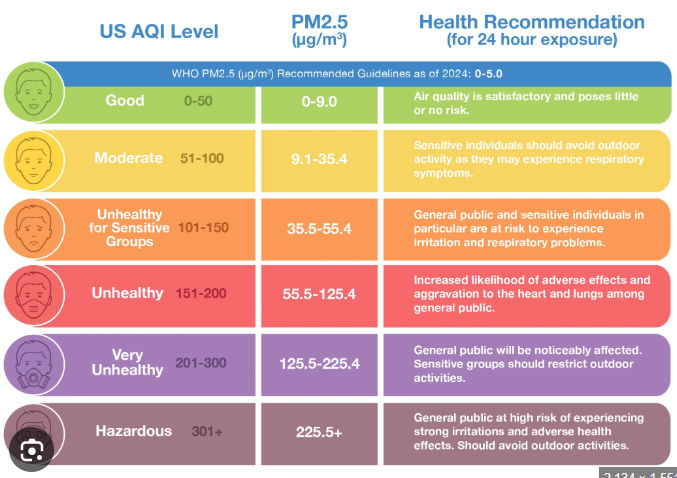

- Chỉ số **AQI (Air Quality Index)** được tính dựa trên **nồng độ của từng chất ô nhiễm** (CO, NO₂, O₃, SO₂, PM2.5,...),  theo công thức **chuẩn của Cơ quan Bảo vệ Môi trường Hoa Kỳ (US EPA)**:

$$
\text{AQI} = \frac{I_{hi} - I_{lo}}{C_{hi} - C_{lo}} \times (C - C_{lo}) + I_{lo}
$$


In [8]:
# --------- 5) Tính AQI (US/EPA) chỉ theo PM2.5 ---------
PM25_BP = [
    (0.0,   9.0,   0,   50),    # Tốt
    (9.1,  35.4,  51,  100),    # Trung bình
    (35.5, 55.4, 101,  150),    # Không lành mạnh cho nhóm nhạy cảm
    (55.5,125.4, 151,  200),    # Không lành mạnh
    (125.5,225.4,201,  300),    # Rất không tốt
    (225.5,500.4,301,  500),    # Nguy hiểm
]

def aqi_from_bp(c, table):
    if c is None:
        return None
    x = float(c)
    for C_lo, C_hi, I_lo, I_hi in table:
        if C_lo <= x <= C_hi:
            return (I_hi - I_lo) / (C_hi - C_lo) * (x - C_lo) + I_lo
    return None

# tính AQI theo PM2.5 và thêm vào bảng df
df['AQI'] = df['PM25'].apply(lambda x: aqi_from_bp(x, PM25_BP)).round(0)


In [9]:
cols = list(df.columns)
cols.insert(cols.index('Timezone') + 1, cols.pop(cols.index('AQI')))
df = df[cols]
df['AQI'] = df['AQI'].astype('Int64')  # kiểu int có thể null


#### **5. Loại bỏ hàng dữ liệu thiếu vượt ngưỡng**

- Một số hàng có thể bị thiếu nhiều giá trị sau khi xử lý.  
- Giữ lại các hàng có **tỷ lệ giá trị hợp lệ ≥ 70%** (nghĩa là tối đa 30% bị thiếu).  
- Điều này giúp loại bỏ các khoảng thời gian dữ liệu đo bị gián đoạn hoặc lỗi cảm biến kéo dài.


In [ ]:

keep_cols = [c for c in ORIG_COLS if c in df.columns]
row_nan = df[keep_cols].isna().mean(axis=1)
df = df[row_nan <= 0.3]


#### **6. Phân tích sơ bộ ngoại lai bằng Boxplot**
Nhận xét:
- Nhận biết giá trị ngoại lai (outliers) theo phân phối của dữ liệu.  
- Đánh giá phạm vi biến động và phân phối giá trị đo thực tế.

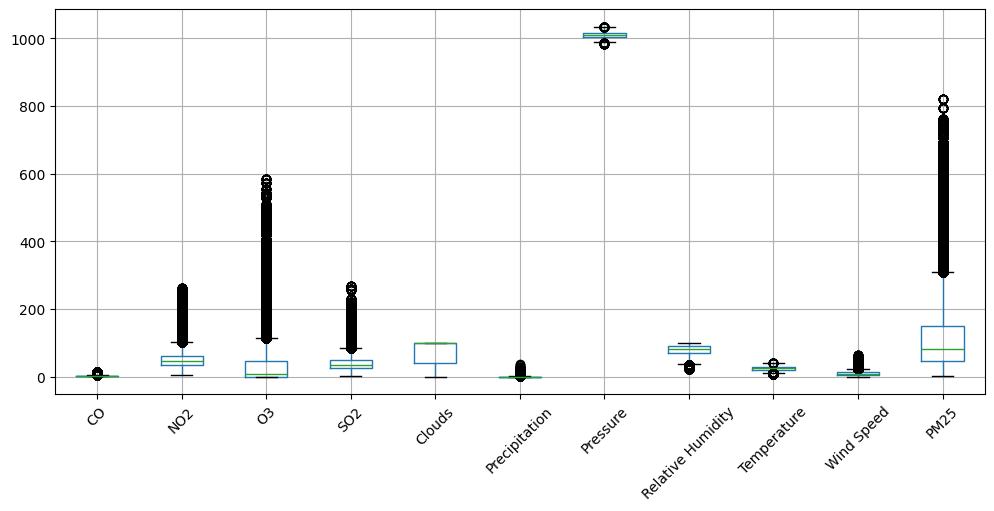

In [11]:
cols = ['CO', 'NO2', 'O3', 'SO2', 'Clouds', 'Precipitation', 'Pressure', 'Relative Humidity', 'Temperature', 'Wind Speed', 'PM25']
plt.figure(figsize=(12,5))
df[cols].boxplot()
plt.xticks(rotation=45)
plt.show()

#### **7. Áp dụng Winsorization để giảm tác động ngoại lai**
- Để tránh các giá trị cực trị ảnh hưởng đến phân tích thống kê, giới hạn dữ liệu trong khoảng **[1st percentile, 99th percentile]** (tức là cắt 1% thấp nhất và 1% cao nhất).
- Làm tròn từng cột theo `ROUND_RULES` đã định nghĩa.  
- Chuyển giá trị `-0.0 → 0.0` để tránh hiển thị số âm giả.  
- Lưu lại tập dữ liệu đã làm sạch thành file `Data_Cleaned.csv`.

In [ ]:

for c in cols:
    if c in df.columns:
        lo = df[c].quantile(0.01)
        hi = df[c].quantile(0.99)
        df[c] = df[c].clip(lower=lo, upper=hi)



In [ ]:

for c in keep_cols:
    if c in ROUND_RULES:
        df[c] = df[c].round(ROUND_RULES[c])
    df[c] = df[c].mask(df[c] == -0.0, 0.0)


In [14]:
df.to_csv('Data_Cleaned.csv', index=False)

Dataset đã sẵn sàng!